# Data Quality Check

Nhiem vu cua phan nay la kiem tra chat luong du lieu truoc khi di vao EDA/model.

Muc tieu can biet du lieu co gi:
- thieu gi
- gia tri nao bat thuong
- cot nao dung duoc
- cot nao can xu ly truoc EDA/model
- ghi lai quyet dinh xu ly

### Buoc 1: Doc lai Parquet de kiem tra co doc duoc khong

Muc tieu: doc lai `train_sessions` va `test_sessions` de chac chan Parquet dung duoc.

Viec can lam:
1. Khoi tao Spark va path.
2. Kiem tra `_SUCCESS`.
3. Doc train/test Parquet.
4. Xem nhanh count, schema va sample.

#### Buoc 1.1: Khoi tao SparkSession

Khoi tao Spark local va khai bao path toi folder Parquet.

In [1]:
import os
import sys
from pathlib import Path

from pyspark import StorageLevel
from pyspark.sql import SparkSession, Window
from pyspark.sql import functions as F

# Neu notebook chay tren Windows local va da cai Hadoop winutils.
HADOOP_HOME_PATH = Path(r"C:\hadoop")
if HADOOP_HOME_PATH.exists():
    os.environ["HADOOP_HOME"] = str(HADOOP_HOME_PATH)
    os.environ["PATH"] = str(HADOOP_HOME_PATH / "bin") + os.pathsep + os.environ.get("PATH", "")

# Dam bao Spark driver va worker dung cung Python environment voi notebook.
os.environ["PYSPARK_PYTHON"] = sys.executable
os.environ["PYSPARK_DRIVER_PYTHON"] = sys.executable

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name.lower() == "week_3":
    PROJECT_ROOT = PROJECT_ROOT.parent

PARQUET_DIR = PROJECT_ROOT / "data_pyspark_parquet"
TRAIN_PARQUET_PATH = PARQUET_DIR / "train_sessions"
TEST_PARQUET_PATH = PARQUET_DIR / "test_sessions"

spark = (
    SparkSession.builder
    .appName("ga_customer_data_quality_check")
    .master("local[*]")
    .config("spark.driver.memory", "6g")
    .config("spark.sql.shuffle.partitions", "8")
    .config("spark.sql.adaptive.enabled", "true")
    .getOrCreate()
)
spark.sparkContext.setLogLevel("WARN")

print("Spark version:", spark.version)
print("Project root:", PROJECT_ROOT)
print("Train parquet:", TRAIN_PARQUET_PATH)
print("Test parquet:", TEST_PARQUET_PATH)

Spark version: 4.1.2
Project root: g:\ds
Train parquet: g:\ds\data_pyspark_parquet\train_sessions
Test parquet: g:\ds\data_pyspark_parquet\test_sessions


#### Buoc 1.2: Kiem tra thu muc Parquet va `_SUCCESS`

Kiem tra folder train/test va marker `_SUCCESS`.

In [2]:
def check_parquet_path(name, path):
    return {
        "dataset": name,
        "path": str(path),
        "path_exists": path.exists(),
        "success_marker_exists": (path / "_SUCCESS").exists(),
    }


parquet_path_checks = [
    check_parquet_path("train_sessions", TRAIN_PARQUET_PATH),
    check_parquet_path("test_sessions", TEST_PARQUET_PATH),
]

for row in parquet_path_checks:
    print(row)

{'dataset': 'train_sessions', 'path': 'g:\\ds\\data_pyspark_parquet\\train_sessions', 'path_exists': True, 'success_marker_exists': True}
{'dataset': 'test_sessions', 'path': 'g:\\ds\\data_pyspark_parquet\\test_sessions', 'path_exists': True, 'success_marker_exists': True}


#### Buoc 1.3: Doc lai train/test Parquet

Doc thanh `train_sessions_df` va `test_sessions_df` de dung cho cac buoc sau.

In [3]:
train_sessions_df = spark.read.parquet(str(TRAIN_PARQUET_PATH))
test_sessions_df = spark.read.parquet(str(TEST_PARQUET_PATH))

print("Doc Parquet thanh cong.")
print("Train columns:", len(train_sessions_df.columns))
print("Test columns:", len(test_sessions_df.columns))

Doc Parquet thanh cong.
Train columns: 61
Test columns: 61


#### Buoc 1.4: Kiem tra nhanh so dong, so cot va schema

Tao bang check doc Parquet, sau do in schema train/test.

In [4]:
def summarize_loaded_parquet(name, df, path):
    row_count = df.count()
    column_count = len(df.columns)
    return {
        "dataset": name,
        "path": str(path),
        "read_success": True,
        "row_count": row_count,
        "column_count": column_count,
        "success_marker_exists": (path / "_SUCCESS").exists(),
    }


parquet_read_check_rows = [
    summarize_loaded_parquet("train_sessions", train_sessions_df, TRAIN_PARQUET_PATH),
    summarize_loaded_parquet("test_sessions", test_sessions_df, TEST_PARQUET_PATH),
]

parquet_read_check_df = spark.createDataFrame(parquet_read_check_rows)
parquet_read_check_df.show(truncate=False)

print("Train schema:")
train_sessions_df.printSchema()

print("Test schema:")
test_sessions_df.printSchema()

+------------+--------------+-----------------------------------------+------------+---------+---------------------+
|column_count|dataset       |path                                     |read_success|row_count|success_marker_exists|
+------------+--------------+-----------------------------------------+------------+---------+---------------------+
|61          |train_sessions|g:\ds\data_pyspark_parquet\train_sessions|true        |1708337  |true                 |
|61          |test_sessions |g:\ds\data_pyspark_parquet\test_sessions |true        |401589   |true                 |
+------------+--------------+-----------------------------------------+------------+---------+---------------------+

Train schema:
root
 |-- fullVisitorId: string (nullable = true)
 |-- visitId: string (nullable = true)
 |-- visitNumber: string (nullable = true)
 |-- visitStartTime: string (nullable = true)
 |-- date: string (nullable = true)
 |-- channelGrouping: string (nullable = true)
 |-- socialEngagementT

#### Buoc 1.5: Xem mot vai dong mau

Xem 5 dong mau voi cac cot dai dien.

In [5]:
preview_columns = [
    "fullVisitorId",
    "visit_id",
    "session_date",
    "channelGrouping",
    "device_category",
    "geo_country",
    "traffic_medium_clean",
    "totals_transactions",
    "transaction_revenue",
    "total_transaction_revenue",
]

print("Train sample:")
train_sessions_df.select(preview_columns).show(5, truncate=False)

print("Test sample:")
test_sessions_df.select(preview_columns).show(5, truncate=False)


Train sample:
+-------------------+----------+------------+---------------+---------------+-------------+--------------------+-------------------+-------------------+-------------------------+
|fullVisitorId      |visit_id  |session_date|channelGrouping|device_category|geo_country  |traffic_medium_clean|totals_transactions|transaction_revenue|total_transaction_revenue|
+-------------------+----------+------------+---------------+---------------+-------------+--------------------+-------------------+-------------------+-------------------------+
|0675225896207031578|1479521643|2016-11-18  |Organic Search |mobile         |Mexico       |(none)              |0                  |0.0                |0.0                      |
|0405493868621572321|1479500779|2016-11-18  |Organic Search |desktop        |Poland       |(none)              |0                  |0.0                |0.0                      |
|3943885042251597234|1479459642|2016-11-18  |Direct         |mobile         |Pakistan     |

### Buoc 2: Table overview

Muc tieu: nam nhanh kich thuoc, so user va khoang thoi gian cua train/test.

Viec can lam:
1. Dem so dong va so user.
2. Lay min/max `session_date`.
3. Khong tinh purchase rate vi label 30 ngay chua duoc tao.

In [6]:
def build_table_overview(name, df):
    row = df.agg(
        F.count(F.lit(1)).alias("row_count"),
        F.countDistinct("fullVisitorId").alias("user_count"),
        F.min("session_date").alias("min_session_date"),
        F.max("session_date").alias("max_session_date"),
    ).collect()[0]

    return {
        "dataset": name,
        "row_count": row["row_count"],
        "user_count": row["user_count"],
        "min_session_date": row["min_session_date"],
        "max_session_date": row["max_session_date"],
    }


table_overview_rows = [
    build_table_overview("train_sessions", train_sessions_df),
    build_table_overview("test_sessions", test_sessions_df),
]

table_overview_df = spark.createDataFrame(table_overview_rows)
table_overview_df.select(
    "dataset",
    "row_count",
    "user_count",
    "min_session_date",
    "max_session_date",
).show(truncate=False)


def get_known_row_count(name, df):
    if "table_overview_rows" in globals():
        for row in table_overview_rows:
            if row["dataset"] == name:
                return row["row_count"]

    if "parquet_read_check_rows" in globals():
        for row in parquet_read_check_rows:
            if row["dataset"] == name:
                return row["row_count"]

    return df.count()


+--------------+---------+----------+----------------+----------------+
|dataset       |row_count|user_count|min_session_date|max_session_date|
+--------------+---------+----------+----------------+----------------+
|train_sessions|1708337  |1323730   |2016-08-01      |2018-04-30      |
|test_sessions |401589   |296530    |2018-05-01      |2018-10-15      |
+--------------+---------+----------+----------------+----------------+



Ghi chu: buoc 02 khong ket luan purchase rate/class imbalance nua vi label 30 ngay se duoc tao sau cleaning.

### Buoc 3: Schema Check

Muc tieu: xem kieu du lieu, null va cardinality cua tung cot.

Cach chay: dem `countDistinct` tung cot de lay ket qua chinh xac va tranh Spark plan qua nang.

Output can co: `dataset | column_name | dtype | non_null_count | null_count | null_pct | unique_count`.

In [7]:
def build_schema_check(name, df):
    total_rows = df.count()
    dtype_by_column = dict(df.dtypes)

    rows = []
    for index, column_name in enumerate(df.columns, start=1):
        print(f"{name}: checking {index}/{len(df.columns)} - {column_name}")
        stats = df.agg(
            F.count(F.col(column_name)).alias("non_null_count"),
            F.countDistinct(F.col(column_name)).alias("unique_count"),
        ).collect()[0]

        non_null_count = stats["non_null_count"]
        null_count = total_rows - non_null_count
        rows.append({
            "dataset": name,
            "column_name": column_name,
            "dtype": dtype_by_column[column_name],
            "non_null_count": non_null_count,
            "null_count": null_count,
            "null_pct": round(null_count / total_rows * 100, 4),
            "unique_count": stats["unique_count"],
        })

    return spark.createDataFrame(rows)


train_schema_check_df = build_schema_check("train_sessions", train_sessions_df)
test_schema_check_df = build_schema_check("test_sessions", test_sessions_df)

schema_check_df = train_schema_check_df.unionByName(test_schema_check_df)

schema_check_df.select(
    "dataset",
    "column_name",
    "dtype",
    "non_null_count",
    "null_count",
    "null_pct",
    "unique_count",
).orderBy("dataset", F.desc("null_pct"), F.desc("unique_count")).show(80, truncate=False)

train_sessions: checking 1/61 - fullVisitorId
train_sessions: checking 2/61 - visitId
train_sessions: checking 3/61 - visitNumber
train_sessions: checking 4/61 - visitStartTime
train_sessions: checking 5/61 - date
train_sessions: checking 6/61 - channelGrouping
train_sessions: checking 7/61 - socialEngagementType
train_sessions: checking 8/61 - device_browser
train_sessions: checking 9/61 - device_operating_system
train_sessions: checking 10/61 - device_is_mobile
train_sessions: checking 11/61 - device_category
train_sessions: checking 12/61 - geo_continent
train_sessions: checking 13/61 - geo_sub_continent
train_sessions: checking 14/61 - geo_country
train_sessions: checking 15/61 - geo_region
train_sessions: checking 16/61 - geo_metro
train_sessions: checking 17/61 - geo_city
train_sessions: checking 18/61 - geo_network_domain
train_sessions: checking 19/61 - traffic_campaign
train_sessions: checking 20/61 - traffic_source
train_sessions: checking 21/61 - traffic_medium
train_session

### Buoc 4: Missing value check

Muc tieu: phan loai cot, xem phan phoi du lieu theo tung loai, sau do moi tinh null/placeholder.

Viec can lam:
1. Phan loai cot: id/time/numeric/category/boolean/binary/target/high-cardinality.
2. Category/boolean/binary: dem exact value counts theo tung cot.
3. Numeric: tinh summary va histogram bins de nhin phan phoi.
4. String/category: tim placeholder nam chinh xac o value nao, cot nao.
5. Xac nhan placeholder roi tinh missing summary.

#### Buoc 4.1: Phan loai cot theo vai tro

Dung dtype, ten cot va cardinality de biet cot nao la category, numeric, boolean, id, time hay target.

In [8]:
HIGH_CARDINALITY_THRESHOLD = 1000

ID_COLUMNS = {"fullVisitorId", "visitId", "visit_id"}
RAW_NUMERIC_STRING_COLUMNS = {"visitNumber", "visitStartTime", "date"}
TIME_COLUMNS = {
    "date",
    "visitStartTime",
    "visit_start_time",
    "visit_start_timestamp",
    "session_date",
    "session_year",
    "session_month",
    "session_day_of_week",
    "session_hour",
}
LABEL_SOURCE_SIGNAL_COLUMNS = {
    "made_purchase",
    "purchase_signal_reason",
    "transaction_revenue",
    "total_transaction_revenue",
    "totals_transactions",
    "totals_transaction_revenue",
    "totals_total_transaction_revenue",
}
REVENUE_SIGNAL_COLUMNS = {
    "transaction_revenue",
    "total_transaction_revenue",
    "totals_transaction_revenue",
    "totals_total_transaction_revenue",
}
NUMERIC_DTYPES = {"int", "bigint", "double", "float", "long"}


def infer_column_role(column_name, dtype, unique_count, row_count):
    if column_name in ID_COLUMNS:
        return "id"
    if column_name in LABEL_SOURCE_SIGNAL_COLUMNS:
        if column_name in {"made_purchase", "purchase_signal_reason"}:
            return "label_debug_signal"
        return "label_source_signal"
    if column_name in TIME_COLUMNS:
        if column_name in {"session_year", "session_month", "session_day_of_week", "session_hour"}:
            return "time_part"
        return "time"
    if dtype == "boolean":
        return "boolean"
    if column_name.startswith("is_") or column_name.startswith("has_"):
        return "binary_flag"
    if dtype == "string":
        if unique_count is not None and unique_count > HIGH_CARDINALITY_THRESHOLD:
            return "high_cardinality_text"
        return "categorical"
    if dtype in NUMERIC_DTYPES:
        if unique_count is not None and unique_count <= 20:
            return "numeric_discrete"
        return "numeric"
    return "other"


column_role_rows = []
for row in schema_check_df.collect():
    row_dict = row.asDict()
    total_rows = row_dict["non_null_count"] + row_dict["null_count"]
    column_role_rows.append({
        "dataset": row_dict["dataset"],
        "column": row_dict["column_name"],
        "dtype": row_dict["dtype"],
        "unique_count": row_dict["unique_count"],
        "null_pct": row_dict["null_pct"],
        "role": infer_column_role(
            row_dict["column_name"],
            row_dict["dtype"],
            row_dict["unique_count"],
            total_rows,
        ),
    })

column_role_df = spark.createDataFrame(column_role_rows)

column_role_df.orderBy("dataset", "role", "column").show(200, truncate=False)

column_role_df.groupBy("dataset", "role").count().orderBy("dataset", "role").show(truncate=False)


+--------------------------------+--------------+---------+--------+---------------------+------------+
|column                          |dataset       |dtype    |null_pct|role                 |unique_count|
+--------------------------------+--------------+---------+--------+---------------------+------------+
|has_gclid                       |test_sessions |int      |0.0     |binary_flag          |2           |
|has_geo_region                  |test_sessions |int      |0.0     |binary_flag          |2           |
|has_traffic_keyword             |test_sessions |int      |0.0     |binary_flag          |2           |
|is_direct_traffic               |test_sessions |int      |0.0     |binary_flag          |2           |
|is_organic_traffic              |test_sessions |int      |0.0     |binary_flag          |2           |
|is_paid_traffic                 |test_sessions |int      |0.0     |binary_flag          |2           |
|is_referral_traffic             |test_sessions |int      |0.0  

#### Buoc 4.2: Exact category/boolean distribution

Dem exact value counts cho cac cot category, boolean, binary flag, time part va label debug/source signal dang categorical.

In [9]:
from pyspark import StorageLevel

DISTRIBUTION_CATEGORY_ROLES = {
    "categorical",
    "boolean",
    "binary_flag",
    "numeric_discrete",
    "time_part",
    "label_debug_signal",
}


def get_columns_by_role(dataset, roles):
    return [
        row["column"]
        for row in (
            column_role_df
            .where((F.col("dataset") == dataset) & (F.col("role").isin(list(roles))))
            .orderBy("column")
            .collect()
        )
    ]


def build_exact_value_distribution(name, df, columns):
    total_rows = get_known_row_count(name, df)
    distribution_dfs = []

    for index, column_name in enumerate(columns, start=1):
        print(f"{name}: value distribution {index}/{len(columns)} - {column_name}")
        one_df = (
            df.groupBy(F.col(column_name).cast("string").alias("value"))
            .count()
            .withColumn("dataset", F.lit(name))
            .withColumn("column", F.lit(column_name))
            .withColumn("pct", F.round(F.col("count") / F.lit(total_rows) * 100, 4))
            .select("dataset", "column", "value", "count", "pct")
        )
        distribution_dfs.append(one_df)

    if not distribution_dfs:
        return spark.createDataFrame([], "dataset string, column string, value string, count long, pct double")

    result_df = distribution_dfs[0]
    for one_df in distribution_dfs[1:]:
        result_df = result_df.unionByName(one_df)
    return result_df


train_category_distribution_columns = get_columns_by_role("train_sessions", DISTRIBUTION_CATEGORY_ROLES)
test_category_distribution_columns = get_columns_by_role("test_sessions", DISTRIBUTION_CATEGORY_ROLES)

train_category_distribution_df = build_exact_value_distribution(
    "train_sessions",
    train_sessions_df,
    train_category_distribution_columns,
)
test_category_distribution_df = build_exact_value_distribution(
    "test_sessions",
    test_sessions_df,
    test_category_distribution_columns,
)

category_distribution_df = train_category_distribution_df.unionByName(test_category_distribution_df)
category_distribution_df = category_distribution_df.persist(StorageLevel.DISK_ONLY)
print("category_distribution_df rows:", category_distribution_df.count())

category_distribution_df.orderBy("dataset", "column", F.desc("count")).show(300, truncate=False)


train_sessions: value distribution 1/39 - browser_family
train_sessions: value distribution 2/39 - channelGrouping
train_sessions: value distribution 3/39 - custom_dimension_value
train_sessions: value distribution 4/39 - device_browser
train_sessions: value distribution 5/39 - device_category
train_sessions: value distribution 6/39 - device_is_mobile
train_sessions: value distribution 7/39 - device_operating_system
train_sessions: value distribution 8/39 - geo_city
train_sessions: value distribution 9/39 - geo_continent
train_sessions: value distribution 10/39 - geo_country
train_sessions: value distribution 11/39 - geo_metro
train_sessions: value distribution 12/39 - geo_region
train_sessions: value distribution 13/39 - geo_region_clean
train_sessions: value distribution 14/39 - geo_sub_continent
train_sessions: value distribution 15/39 - has_gclid
train_sessions: value distribution 16/39 - has_geo_region
train_sessions: value distribution 17/39 - has_traffic_keyword
train_sessions: 

#### Buoc 4.3: Compact category distribution

Gom value counts thanh mot dong cho moi cot de doc nhanh.

In [10]:
CATEGORY_COMPACT_TOP_N = 12
from pyspark.sql import Window


ranked_category_distribution_df = category_distribution_df.withColumn(
    "rank",
    F.row_number().over(
        Window.partitionBy("dataset", "column").orderBy(F.desc("count"), F.asc_nulls_last(F.col("value")))
    ),
)

top_category_text_df = ranked_category_distribution_df.where(F.col("rank") <= CATEGORY_COMPACT_TOP_N).withColumn(
    "value_text",
    F.concat(
        F.coalesce(F.col("value"), F.lit("<null>")),
        F.lit(": "),
        F.format_number(F.col("pct"), 2),
        F.lit("%"),
    ),
)

category_distribution_summary_df = (
    top_category_text_df
    .groupBy("dataset", "column")
    .agg(
        F.sum("pct").alias("shown_pct"),
        F.sort_array(
            F.collect_list(
                F.struct(
                    F.col("rank").alias("rank"),
                    F.col("value_text").alias("value_text"),
                )
            )
        ).alias("items"),
    )
    .withColumn("value_distribution", F.expr("array_join(transform(items, x -> x.value_text), ' | ')"))
    .withColumn("other_pct", F.round(F.lit(100.0) - F.col("shown_pct"), 4))
    .drop("items")
)

category_distribution_summary_df.orderBy("dataset", "column").show(200, truncate=False)

+--------------+-----------------------+------------------+--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+---------+
|dataset       |column                 |shown_pct         |value_distribution                                                                                                                                                                                                                                                                                                    

#### Buoc 4.4: Numeric distribution

Tinh summary va histogram exact count theo bin cho cac cot numeric.

In [11]:
from pyspark import StorageLevel

NUMERIC_HISTOGRAM_BINS = 30
NUMERIC_DISTRIBUTION_ROLES = {"numeric", "label_source_signal"}


def get_numeric_distribution_columns(dataset):
    return [
        row["column"]
        for row in (
            column_role_df
            .where((F.col("dataset") == dataset) & (F.col("role").isin(list(NUMERIC_DISTRIBUTION_ROLES))))
            .orderBy("column")
            .collect()
        )
    ]


def build_numeric_summary(name, df, columns):
    rows = []
    total_rows = get_known_row_count(name, df)

    for index, column_name in enumerate(columns, start=1):
        print(f"{name}: numeric summary {index}/{len(columns)} - {column_name}")
        stats = df.agg(
            F.count(F.col(column_name)).alias("non_null_count"),
            F.min(F.col(column_name)).alias("min"),
            F.max(F.col(column_name)).alias("max"),
            F.mean(F.col(column_name)).alias("mean"),
            F.stddev(F.col(column_name)).alias("stddev"),
        ).collect()[0]

        rows.append({
            "dataset": name,
            "column": column_name,
            "non_null_count": stats["non_null_count"],
            "null_count": total_rows - stats["non_null_count"],
            "min": None if stats["min"] is None else float(stats["min"]),
            "max": None if stats["max"] is None else float(stats["max"]),
            "mean": None if stats["mean"] is None else float(stats["mean"]),
            "stddev": None if stats["stddev"] is None else float(stats["stddev"]),
        })

    return spark.createDataFrame(rows)


def build_numeric_histogram(name, df, numeric_summary_df, bins=NUMERIC_HISTOGRAM_BINS):
    histogram_dfs = []
    total_rows = get_known_row_count(name, df)

    for row in numeric_summary_df.collect():
        column_name = row["column"]
        min_value = row["min"]
        max_value = row["max"]
        if min_value is None or max_value is None:
            continue

        if min_value == max_value:
            one_df = spark.createDataFrame([{
                "dataset": name,
                "column": column_name,
                "bin_index": 0,
                "bin_start": float(min_value),
                "bin_end": float(max_value),
                "count": row["non_null_count"],
                "pct": round(row["non_null_count"] / total_rows * 100, 4),
            }])
            histogram_dfs.append(one_df)
            continue

        bin_width = (max_value - min_value) / bins
        bin_index_col = F.floor((F.col(column_name).cast("double") - F.lit(min_value)) / F.lit(bin_width)).cast("int")
        bin_index_col = F.when(bin_index_col >= bins, bins - 1).otherwise(bin_index_col)

        one_df = (
            df.where(F.col(column_name).isNotNull())
            .withColumn("bin_index", bin_index_col)
            .groupBy("bin_index")
            .count()
            .withColumn("dataset", F.lit(name))
            .withColumn("column", F.lit(column_name))
            .withColumn("bin_start", F.lit(min_value) + F.col("bin_index") * F.lit(bin_width))
            .withColumn("bin_end", F.lit(min_value) + (F.col("bin_index") + 1) * F.lit(bin_width))
            .withColumn("pct", F.round(F.col("count") / F.lit(total_rows) * 100, 4))
            .select("dataset", "column", "bin_index", "bin_start", "bin_end", "count", "pct")
        )
        histogram_dfs.append(one_df)

    if not histogram_dfs:
        return spark.createDataFrame([], "dataset string, column string, bin_index int, bin_start double, bin_end double, count long, pct double")

    result_df = histogram_dfs[0]
    for one_df in histogram_dfs[1:]:
        result_df = result_df.unionByName(one_df)
    return result_df


train_numeric_columns = get_numeric_distribution_columns("train_sessions")
test_numeric_columns = get_numeric_distribution_columns("test_sessions")

train_numeric_summary_df = build_numeric_summary("train_sessions", train_sessions_df, train_numeric_columns)
test_numeric_summary_df = build_numeric_summary("test_sessions", test_sessions_df, test_numeric_columns)
numeric_summary_df = train_numeric_summary_df.unionByName(test_numeric_summary_df)

train_numeric_histogram_df = build_numeric_histogram("train_sessions", train_sessions_df, train_numeric_summary_df)
test_numeric_histogram_df = build_numeric_histogram("test_sessions", test_sessions_df, test_numeric_summary_df)
numeric_histogram_df = train_numeric_histogram_df.unionByName(test_numeric_histogram_df)
numeric_histogram_df = numeric_histogram_df.persist(StorageLevel.DISK_ONLY)
print("numeric_histogram_df rows:", numeric_histogram_df.count())

numeric_summary_df.orderBy("dataset", "column").show(100, truncate=False)
numeric_histogram_df.orderBy("dataset", "column", "bin_index").show(200, truncate=False)


train_sessions: numeric summary 1/10 - total_transaction_revenue
train_sessions: numeric summary 2/10 - totals_hits
train_sessions: numeric summary 3/10 - totals_pageviews
train_sessions: numeric summary 4/10 - totals_session_quality_dim
train_sessions: numeric summary 5/10 - totals_time_on_site
train_sessions: numeric summary 6/10 - totals_total_transaction_revenue
train_sessions: numeric summary 7/10 - totals_transaction_revenue
train_sessions: numeric summary 8/10 - totals_transactions
train_sessions: numeric summary 9/10 - transaction_revenue
train_sessions: numeric summary 10/10 - visit_number
test_sessions: numeric summary 1/10 - total_transaction_revenue
test_sessions: numeric summary 2/10 - totals_hits
test_sessions: numeric summary 3/10 - totals_pageviews
test_sessions: numeric summary 4/10 - totals_session_quality_dim
test_sessions: numeric summary 5/10 - totals_time_on_site
test_sessions: numeric summary 6/10 - totals_total_transaction_revenue
test_sessions: numeric summary 

#### Buoc 4.5: Ve numeric distribution

Ve histogram line chart cho cac cot numeric quan trong.

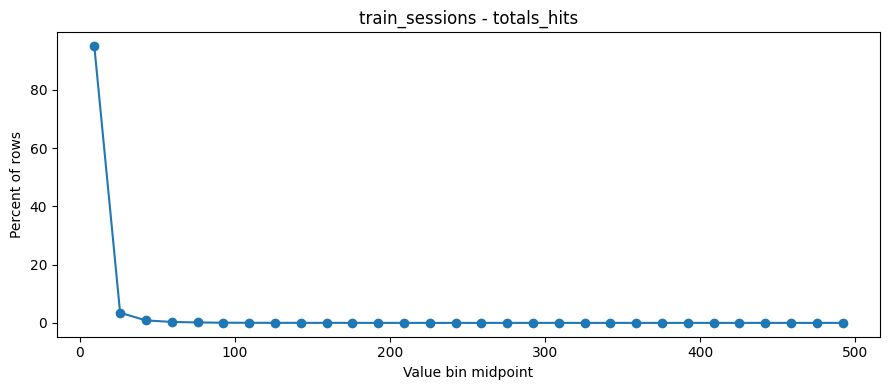

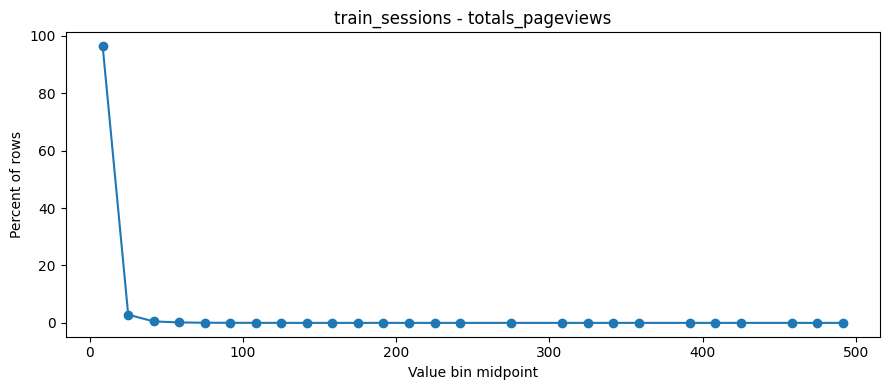

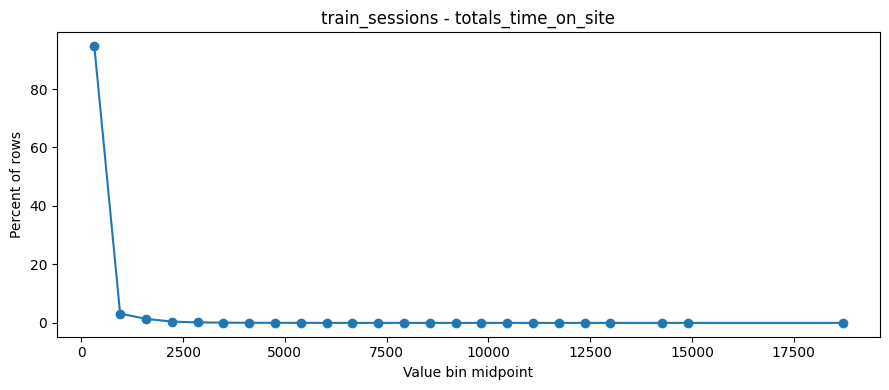

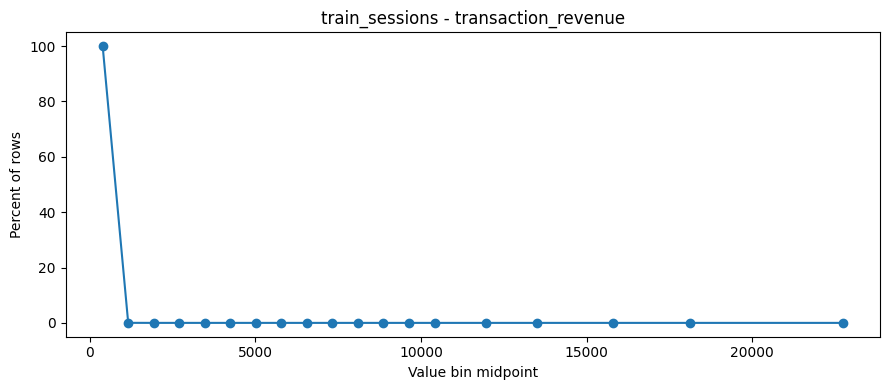

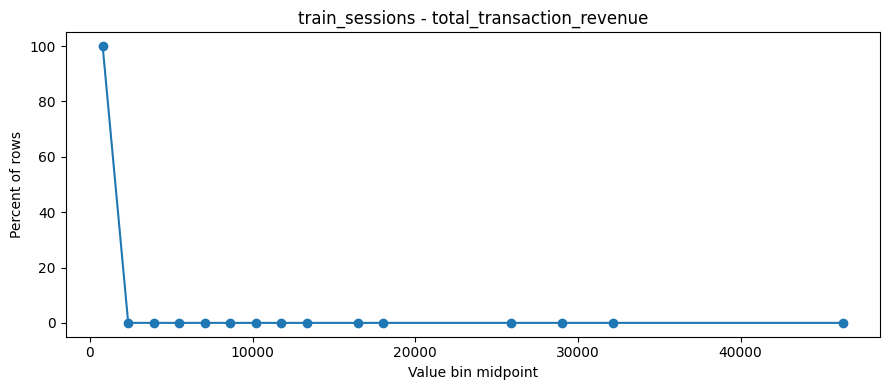

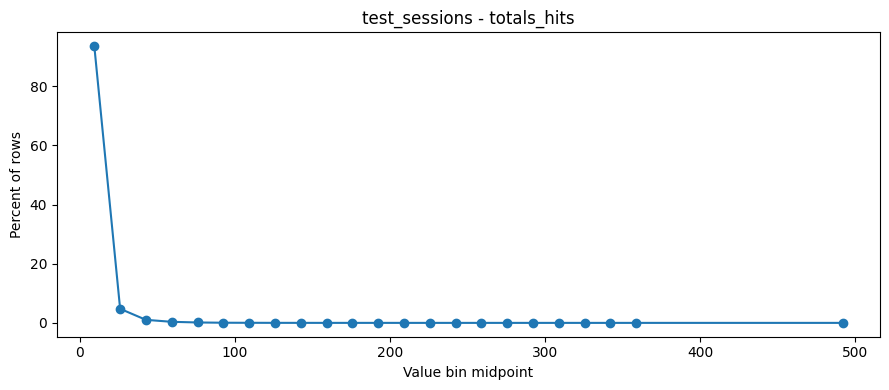

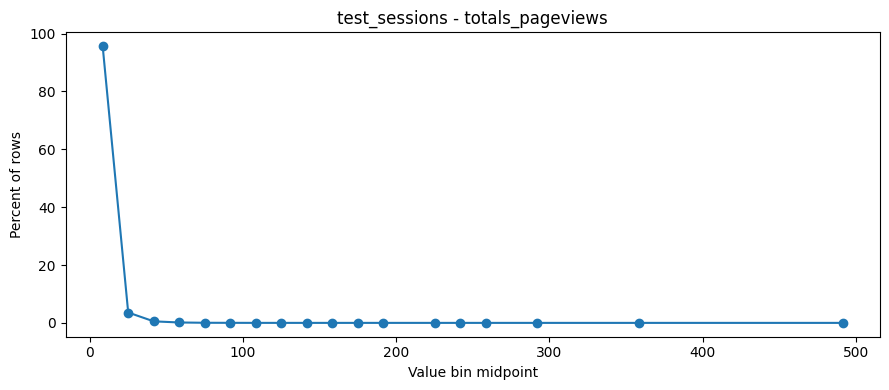

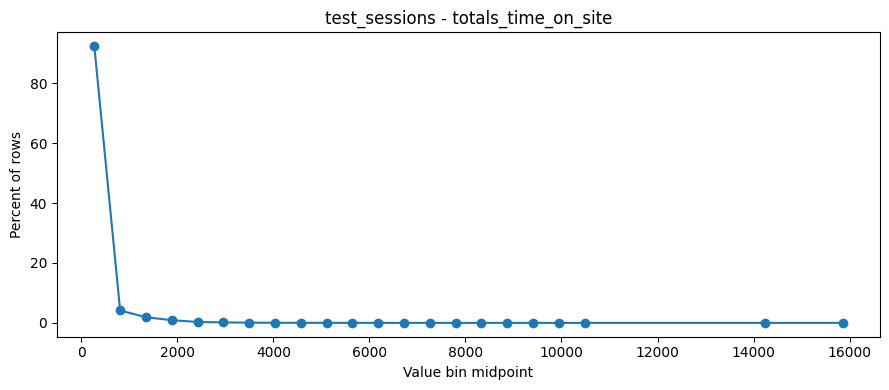

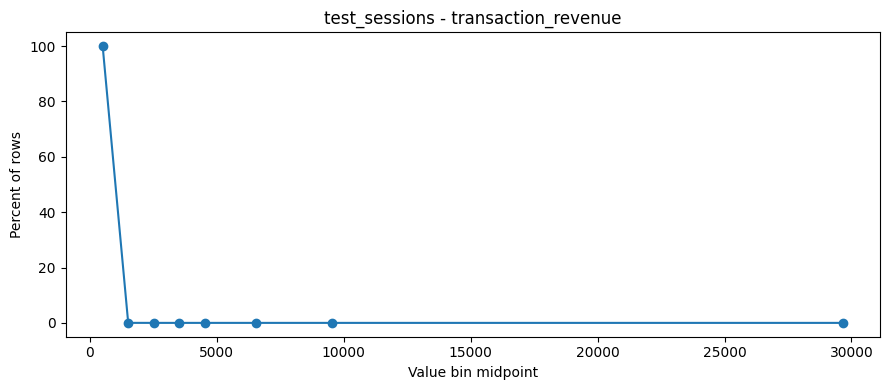

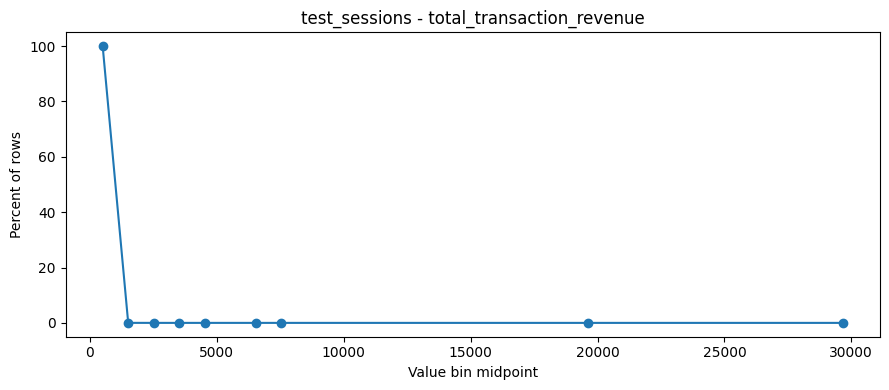

In [12]:
import matplotlib.pyplot as plt

NUMERIC_PLOT_COLUMNS = [
    "totals_hits",
    "totals_pageviews",
    "totals_time_on_site",
    "transaction_revenue",
    "total_transaction_revenue",
]


def plot_numeric_histograms(histogram_df, dataset, columns):
    plot_df = (
        histogram_df
        .where((F.col("dataset") == dataset) & (F.col("column").isin(columns)))
        .orderBy("column", "bin_index")
        .toPandas()
    )

    for column_name in columns:
        one_col = plot_df[plot_df["column"] == column_name].copy()
        if one_col.empty:
            continue

        one_col["bin_midpoint"] = (one_col["bin_start"] + one_col["bin_end"]) / 2
        plt.figure(figsize=(9, 4))
        plt.plot(one_col["bin_midpoint"], one_col["pct"], marker="o")
        plt.title(f"{dataset} - {column_name}")
        plt.xlabel("Value bin midpoint")
        plt.ylabel("Percent of rows")
        plt.tight_layout()
        plt.show()


plot_numeric_histograms(numeric_histogram_df, "train_sessions", NUMERIC_PLOT_COLUMNS)
plot_numeric_histograms(numeric_histogram_df, "test_sessions", NUMERIC_PLOT_COLUMNS)

#### Buoc 4.6: Profile gia tri string/category

Xem top values va cac gia tri co dau hieu placeholder trong tung cot.

In [13]:
STRING_TOP_N = 20
from pyspark.sql import Window

PLACEHOLDER_CANDIDATE_REGEX = r"^\s*$|unknown|not available|not set|not provided|^\(not|^\(none\)$|^none$|^n/a$"

# Dung lai `category_distribution_df` da tinh exact o buoc 4.2 de tranh scan du lieu lap lai.
string_like_columns_df = column_role_df.where(
    F.col("role").isin(["categorical", "target_reason"])
).select("dataset", "column")

string_top_values_df = (
    category_distribution_df
    .join(string_like_columns_df, on=["dataset", "column"], how="inner")
    .withColumn(
        "rank",
        F.row_number().over(
            Window.partitionBy("dataset", "column").orderBy(F.desc("count"), F.asc_nulls_last(F.col("value")))
        ),
    )
    .where(F.col("rank") <= STRING_TOP_N)
    .select(
        "dataset",
        "column",
        F.col("value").alias("raw_value"),
        F.lower(F.trim(F.col("value"))).alias("normalized_value"),
        "count",
        "pct",
    )
)

placeholder_candidate_df = (
    category_distribution_df
    .join(string_like_columns_df, on=["dataset", "column"], how="inner")
    .withColumn("candidate_value", F.lower(F.trim(F.col("value"))))
    .where(F.col("candidate_value").rlike(PLACEHOLDER_CANDIDATE_REGEX))
    .select("dataset", "column", "candidate_value", "count", "pct")
)

print("Top string/category values:")
string_top_values_df.orderBy("dataset", "column", F.desc("count")).show(200, truncate=False)

print("Placeholder candidates:")
placeholder_candidate_df.orderBy("dataset", F.desc("pct"), "column").show(200, truncate=False)

Top string/category values:
+-------------+-----------------------+---------------------------------+---------------------------------+------+-------+
|dataset      |column                 |raw_value                        |normalized_value                 |count |pct    |
+-------------+-----------------------+---------------------------------+---------------------------------+------+-------+
|test_sessions|browser_family         |Chrome                           |chrome                           |305534|76.0813|
|test_sessions|browser_family         |Safari                           |safari                           |59823 |14.8966|
|test_sessions|browser_family         |Other                            |other                            |14791 |3.6831 |
|test_sessions|browser_family         |Firefox                          |firefox                          |12527 |3.1194 |
|test_sessions|browser_family         |Internet Explorer                |internet explorer                |4528

#### Buoc 4.7: Compact placeholder/category profile

Gom top values va placeholder candidates ve 1 dong cho moi cot de de doc hon.

In [14]:
value_text_df = string_top_values_df.withColumn(
    "value_text",
    F.concat(
        F.coalesce(F.col("raw_value").cast("string"), F.lit("<null>")),
        F.lit(": "),
        F.format_number(F.col("pct"), 2),
        F.lit("%"),
    ),
)

compact_category_profile_df = (
    value_text_df
    .groupBy("dataset", "column")
    .agg(
        F.sum("pct").alias("top_values_pct"),
        F.sort_array(
            F.collect_list(
                F.struct(
                    (-F.col("count")).alias("sort_count"),
                    F.col("value_text").alias("value_text"),
                )
            )
        ).alias("top_value_items"),
    )
    .withColumn("top_values", F.expr("array_join(transform(top_value_items, x -> x.value_text), ' | ')"))
    .withColumn("other_pct", F.round(F.lit(100.0) - F.col("top_values_pct"), 4))
    .drop("top_value_items")
)

candidate_text_df = placeholder_candidate_df.withColumn(
    "candidate_text",
    F.concat(
        F.coalesce(F.col("candidate_value"), F.lit("<null>")),
        F.lit(": "),
        F.format_number(F.col("pct"), 2),
        F.lit("%"),
    ),
)

compact_placeholder_candidate_df = (
    candidate_text_df
    .groupBy("dataset", "column")
    .agg(
        F.sort_array(
            F.collect_list(
                F.struct(
                    (-F.col("count")).alias("sort_count"),
                    F.col("candidate_text").alias("candidate_text"),
                )
            )
        ).alias("candidate_items")
    )
    .withColumn("placeholder_candidates", F.expr("array_join(transform(candidate_items, x -> x.candidate_text), ' | ')"))
    .drop("candidate_items")
)

category_profile_summary_df = (
    compact_category_profile_df
    .join(compact_placeholder_candidate_df, on=["dataset", "column"], how="left")
    .select(
        "dataset",
        "column",
        "top_values",
        F.round(F.col("top_values_pct"), 4).alias("top_values_pct"),
        "other_pct",
        "placeholder_candidates",
    )
)

category_profile_summary_df.orderBy("dataset", "column").show(200, truncate=False)

+--------------+-----------------------+----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+--------------+---------+------------------

#### Buoc 4.8: Ve bieu do category

Ve top values cho mot so cot quan trong de nhin phan phoi nhanh.

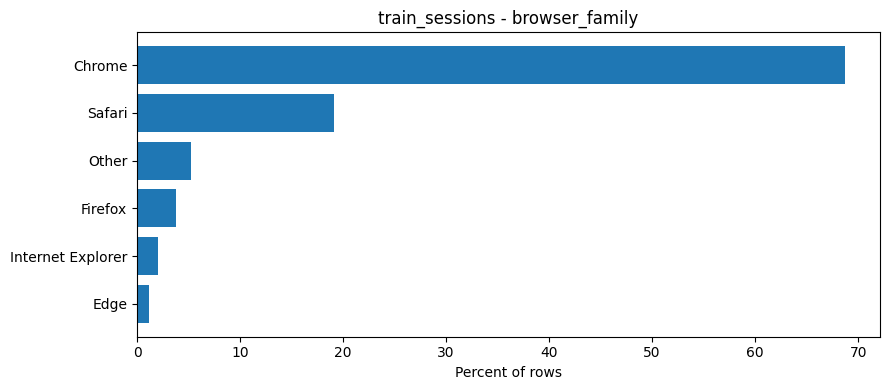

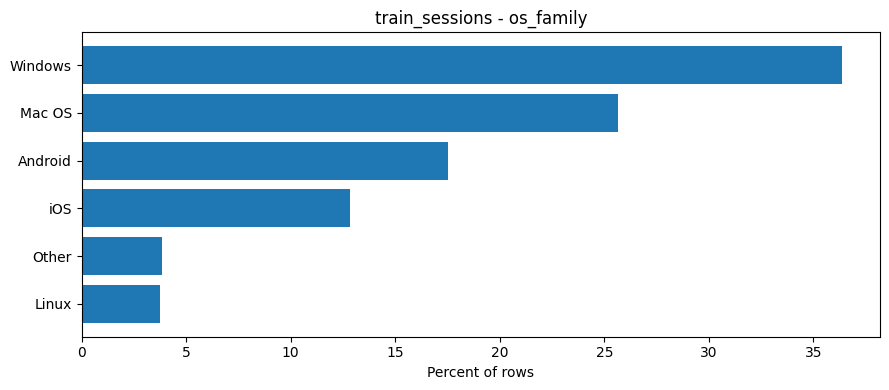

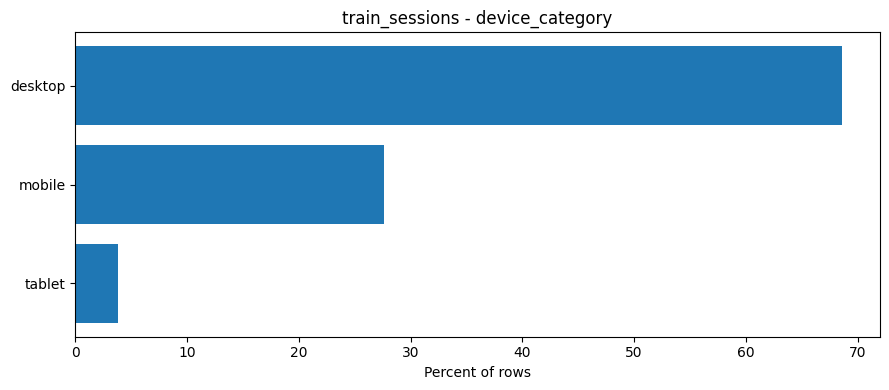

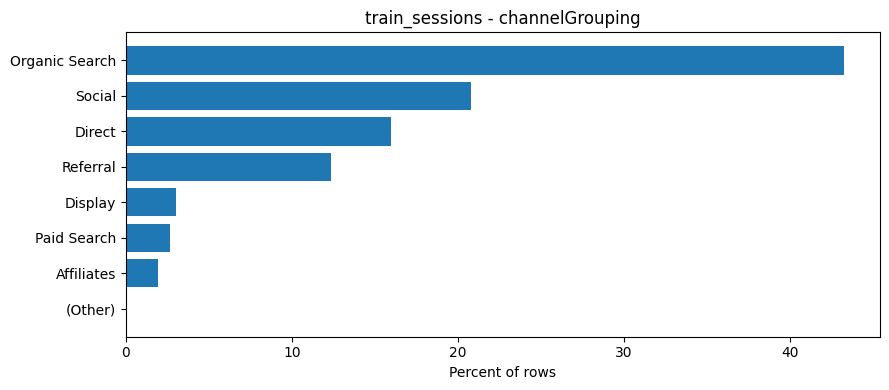

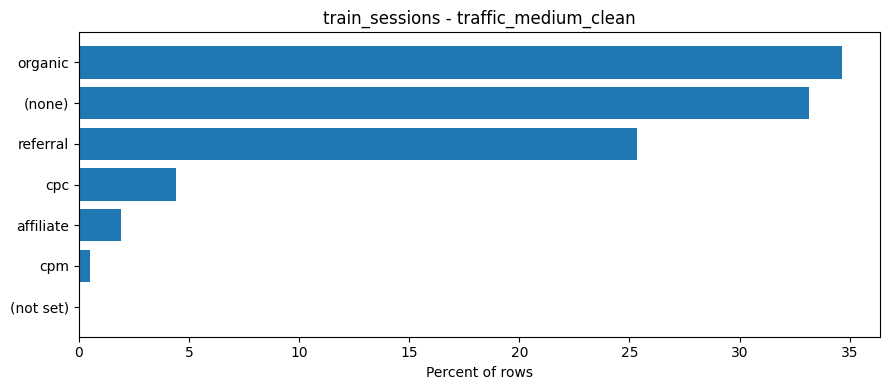

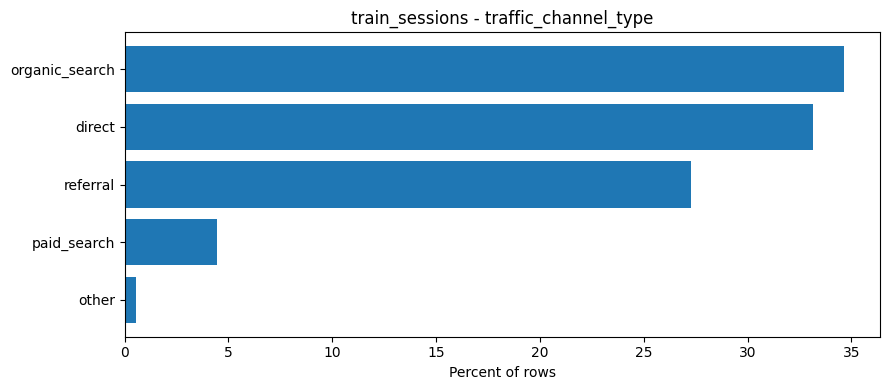

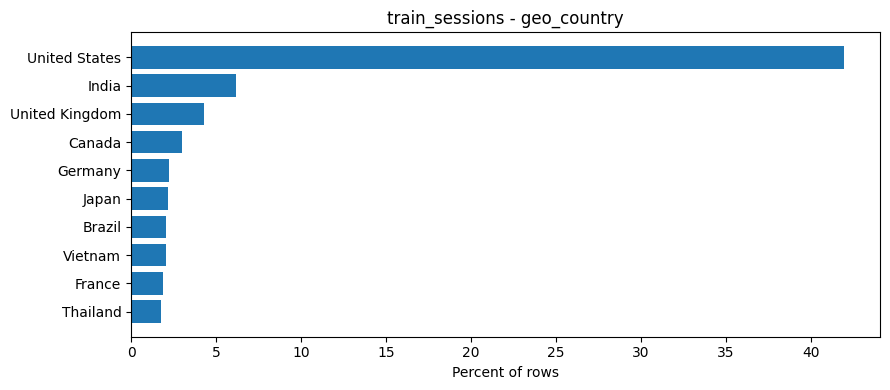

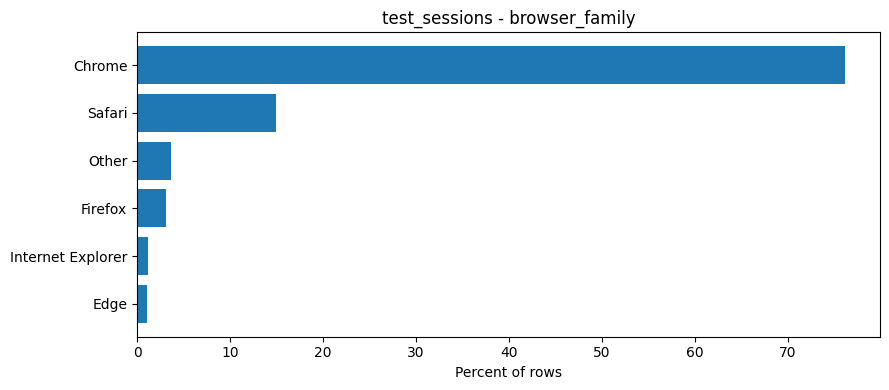

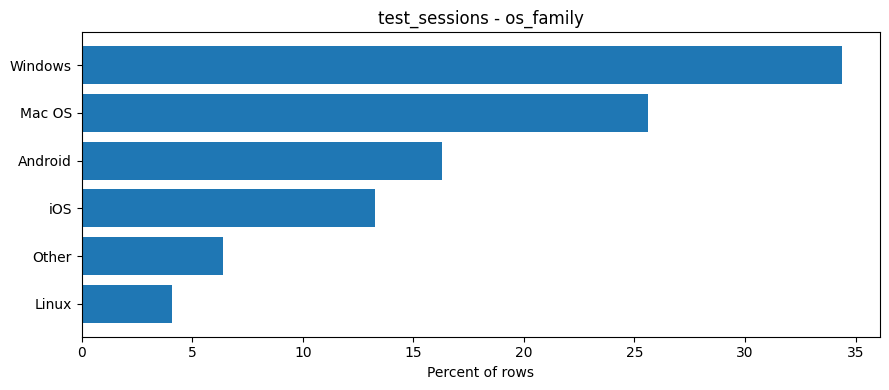

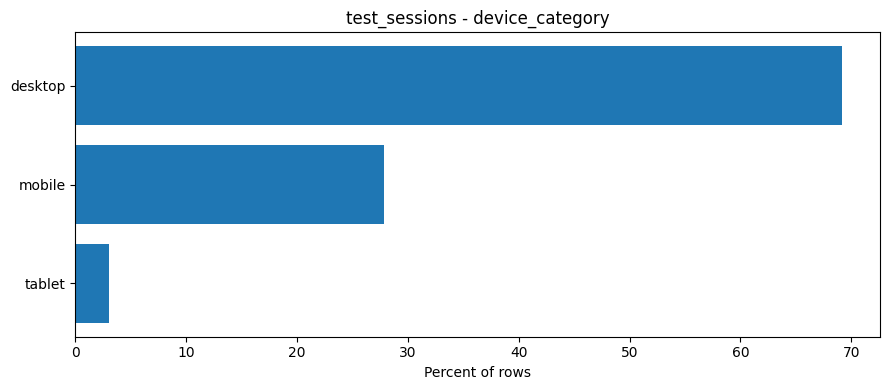

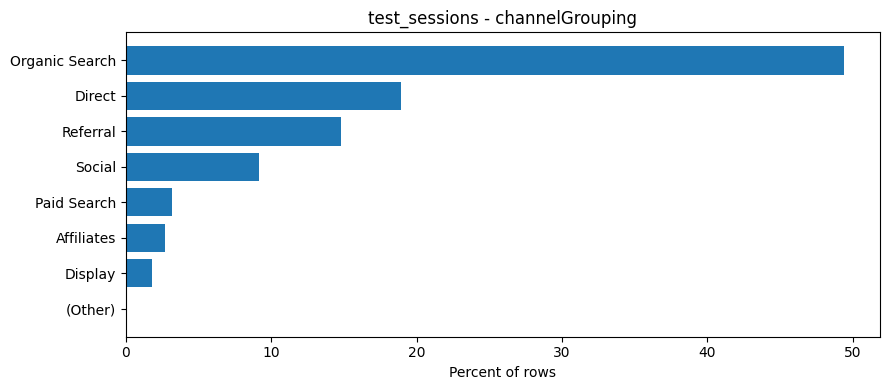

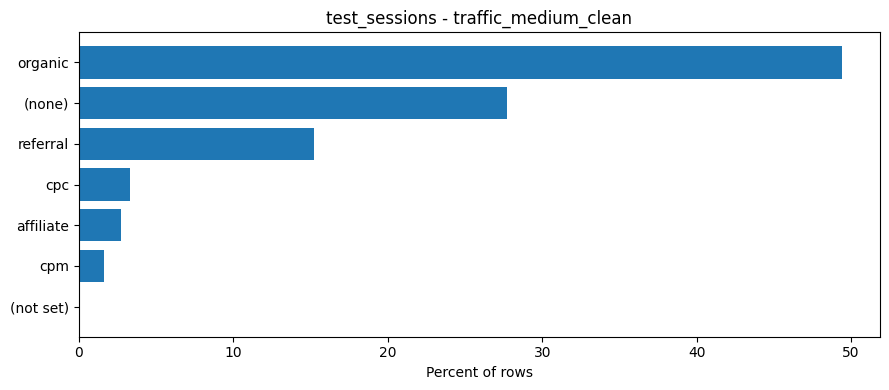

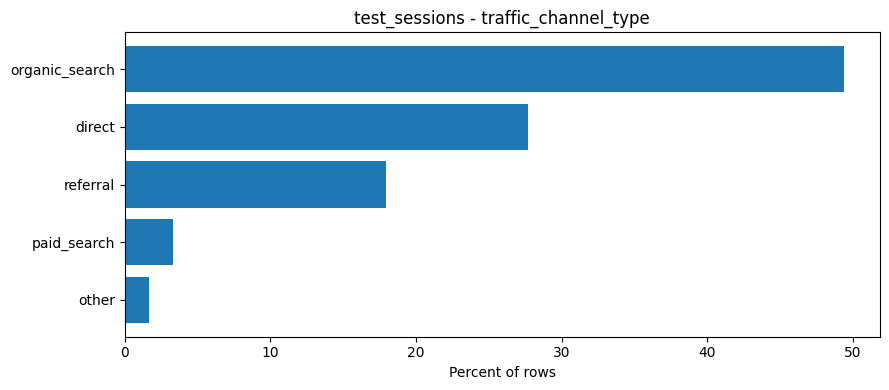

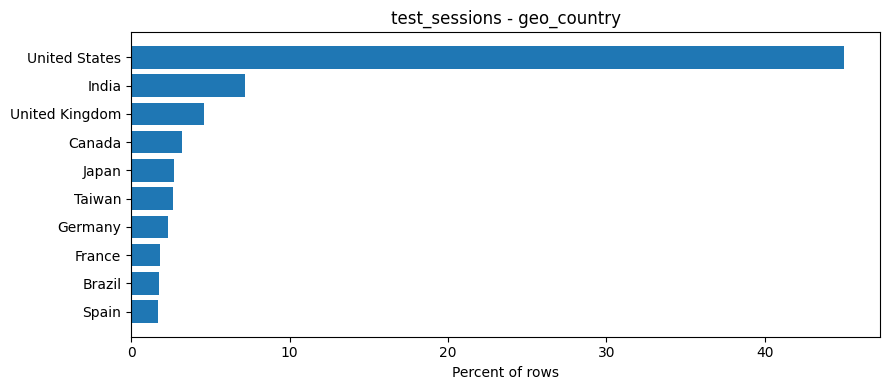

In [15]:
import matplotlib.pyplot as plt

CATEGORY_PLOT_COLUMNS = [
    "browser_family",
    "os_family",
    "device_category",
    "channelGrouping",
    "traffic_medium_clean",
    "traffic_channel_type",
    "geo_country",
]


def plot_category_distribution(distribution_df, dataset, columns, top_n=10):
    plot_df = (
        distribution_df
        .where((F.col("dataset") == dataset) & (F.col("column").isin(columns)))
        .select("column", "value", "pct")
        .toPandas()
    )

    for column_name in columns:
        one_col = (
            plot_df[plot_df["column"] == column_name]
            .sort_values("pct", ascending=False)
            .head(top_n)
        )
        if one_col.empty:
            continue

        labels = one_col["value"].fillna("<null>").astype(str)
        values = one_col["pct"]

        plt.figure(figsize=(9, 4))
        plt.barh(labels[::-1], values[::-1])
        plt.title(f"{dataset} - {column_name}")
        plt.xlabel("Percent of rows")
        plt.tight_layout()
        plt.show()


plot_category_distribution(category_distribution_df, "train_sessions", CATEGORY_PLOT_COLUMNS, top_n=10)
plot_category_distribution(category_distribution_df, "test_sessions", CATEGORY_PLOT_COLUMNS, top_n=10)

#### Buoc 4.9: Missing summary

Dung danh sach placeholder da xac nhan de tinh null va placeholder rate.

In [16]:
# Sau khi xem `placeholder_candidate_df`, chi dua vao day cac value thuc su la missing/placeholder.
# Vi du `(none)` trong traffic_medium co the la direct traffic, nen chua dua vao confirmed list.
CONFIRMED_PLACEHOLDER_VALUES = [
    "(not set)",
    "not available in demo dataset",
    "unknown.unknown",
    "(not provided)",
    "not provided",
    "unknown",
    "",
]


def missing_value_decision(null_pct, placeholder_pct):
    affected_pct = max(null_pct, placeholder_pct)
    if affected_pct >= 80:
        return "consider_drop_or_flag"
    if affected_pct >= 30:
        return "clean_or_impute_before_model"
    if affected_pct > 0:
        return "keep_but_clean_placeholder"
    return "keep"


def get_known_row_count(name, df):
    if "table_overview_rows" in globals():
        for row in table_overview_rows:
            if row["dataset"] == name:
                return row["row_count"]

    if "parquet_read_check_rows" in globals():
        for row in parquet_read_check_rows:
            if row["dataset"] == name:
                return row["row_count"]

    return df.count()


def build_missing_value_check(name, df):
    total_rows = get_known_row_count(name, df)
    dtype_by_column = dict(df.dtypes)
    string_columns = {column_name for column_name, dtype in df.dtypes if dtype == "string"}

    rows = []
    for index, column_name in enumerate(df.columns, start=1):
        print(f"{name}: missing check {index}/{len(df.columns)} - {column_name}")
        if column_name in string_columns:
            clean_col = F.lower(F.trim(F.col(column_name)))
            stats = df.agg(
                F.count(F.col(column_name)).alias("non_null_count"),
                F.sum(F.when(clean_col.isin(CONFIRMED_PLACEHOLDER_VALUES), 1).otherwise(0)).alias("placeholder_count"),
            ).collect()[0]
        else:
            stats = df.agg(
                F.count(F.col(column_name)).alias("non_null_count"),
            ).collect()[0]

        non_null_count = stats["non_null_count"]
        null_count = total_rows - non_null_count
        placeholder_count = stats["placeholder_count"] if column_name in string_columns else 0
        null_pct = round(null_count / total_rows * 100, 4)
        placeholder_pct = round(placeholder_count / total_rows * 100, 4)

        rows.append({
            "dataset": name,
            "column": column_name,
            "dtype": dtype_by_column[column_name],
            "null_count": null_count,
            "null_pct": null_pct,
            "placeholder_count": placeholder_count,
            "placeholder_pct": placeholder_pct,
            "decision": missing_value_decision(null_pct, placeholder_pct),
        })

    return spark.createDataFrame(rows)


train_missing_value_check_df = build_missing_value_check("train_sessions", train_sessions_df)
test_missing_value_check_df = build_missing_value_check("test_sessions", test_sessions_df)

missing_value_check_df = train_missing_value_check_df.unionByName(test_missing_value_check_df)

missing_value_check_df.select(
    "dataset",
    "column",
    "dtype",
    "null_count",
    "null_pct",
    "placeholder_count",
    "placeholder_pct",
    "decision",
).orderBy("dataset", F.desc("placeholder_pct"), F.desc("null_pct")).show(100, truncate=False)

train_sessions: missing check 1/61 - fullVisitorId
train_sessions: missing check 2/61 - visitId
train_sessions: missing check 3/61 - visitNumber
train_sessions: missing check 4/61 - visitStartTime
train_sessions: missing check 5/61 - date
train_sessions: missing check 6/61 - channelGrouping
train_sessions: missing check 7/61 - socialEngagementType
train_sessions: missing check 8/61 - device_browser
train_sessions: missing check 9/61 - device_operating_system
train_sessions: missing check 10/61 - device_is_mobile
train_sessions: missing check 11/61 - device_category
train_sessions: missing check 12/61 - geo_continent
train_sessions: missing check 13/61 - geo_sub_continent
train_sessions: missing check 14/61 - geo_country
train_sessions: missing check 15/61 - geo_region
train_sessions: missing check 16/61 - geo_metro
train_sessions: missing check 17/61 - geo_city
train_sessions: missing check 18/61 - geo_network_domain
train_sessions: missing check 19/61 - traffic_campaign
train_sessions

### Buoc 5: Duplicate va Key check

Muc tieu: kiem tra session-level key `fullVisitorId + visit_id` co unique khong.

Viec can lam:
1. Kiem tra key null.
2. Dem total rows va distinct session key.
3. Dem so key bi trung va so dong duplicate du.
4. Xem sample duplicate key neu co.

In [17]:
from pyspark import StorageLevel

SESSION_KEY_COLUMNS = ["fullVisitorId", "visit_id"]


def get_known_row_count(name, df):
    if "table_overview_rows" in globals():
        for row in table_overview_rows:
            if row["dataset"] == name:
                return row["row_count"]

    if "parquet_read_check_rows" in globals():
        for row in parquet_read_check_rows:
            if row["dataset"] == name:
                return row["row_count"]

    return df.count()


def build_duplicate_key_check(name, df):
    total_rows = get_known_row_count(name, df)
    null_key_rows = df.where(
        F.col("fullVisitorId").isNull() | F.col("visit_id").isNull()
    ).count()

    key_counts_df = (
        df.groupBy(*SESSION_KEY_COLUMNS)
        .count()
        .persist(StorageLevel.DISK_ONLY)
    )

    distinct_session_keys = key_counts_df.count()

    duplicate_stats = key_counts_df.agg(
        F.sum(F.when(F.col("count") > 1, 1).otherwise(0)).alias("duplicate_key_count"),
        F.sum(F.when(F.col("count") > 1, F.col("count")).otherwise(0)).alias("duplicate_rows_involved"),
        F.sum(F.when(F.col("count") > 1, F.col("count") - 1).otherwise(0)).alias("duplicate_extra_rows"),
        F.max("count").alias("max_rows_per_key"),
    ).collect()[0]

    duplicate_key_sample_rows = [
        row.asDict()
        for row in (
        key_counts_df
        .where(F.col("count") > 1)
        .withColumn("dataset", F.lit(name))
        .select("dataset", "fullVisitorId", "visit_id", F.col("count").alias("rows_per_key"))
        .orderBy(F.desc("rows_per_key"), "fullVisitorId", "visit_id")
        .limit(20)
        .collect()
        )
    ]

    row = {
        "dataset": name,
        "total_rows": total_rows,
        "null_key_rows": null_key_rows,
        "null_key_pct": round(null_key_rows / total_rows * 100, 4),
        "distinct_session_keys": distinct_session_keys,
        "duplicate_key_count": duplicate_stats["duplicate_key_count"] or 0,
        "duplicate_rows_involved": duplicate_stats["duplicate_rows_involved"] or 0,
        "duplicate_extra_rows": duplicate_stats["duplicate_extra_rows"] or 0,
        "duplicate_extra_pct": round((duplicate_stats["duplicate_extra_rows"] or 0) / total_rows * 100, 4),
        "max_rows_per_key": duplicate_stats["max_rows_per_key"] or 0,
        "key_is_unique": distinct_session_keys == total_rows and null_key_rows == 0,
    }

    key_counts_df.unpersist()
    return row, duplicate_key_sample_rows


train_duplicate_key_row, train_duplicate_key_sample_rows = build_duplicate_key_check("train_sessions", train_sessions_df)
test_duplicate_key_row, test_duplicate_key_sample_rows = build_duplicate_key_check("test_sessions", test_sessions_df)

duplicate_key_check_df = spark.createDataFrame([
    train_duplicate_key_row,
    test_duplicate_key_row,
])

duplicate_key_sample_rows = train_duplicate_key_sample_rows + test_duplicate_key_sample_rows
if duplicate_key_sample_rows:
    duplicate_key_sample_df = spark.createDataFrame(duplicate_key_sample_rows)
else:
    duplicate_key_sample_df = spark.createDataFrame([], "dataset string, fullVisitorId string, visit_id long, rows_per_key long")

duplicate_key_check_df.select(
    "dataset",
    "total_rows",
    "distinct_session_keys",
    "null_key_rows",
    "null_key_pct",
    "duplicate_key_count",
    "duplicate_rows_involved",
    "duplicate_extra_rows",
    "duplicate_extra_pct",
    "max_rows_per_key",
    "key_is_unique",
).show(truncate=False)

print("Duplicate key sample:")
duplicate_key_sample_df.show(20, truncate=False)

+--------------+----------+---------------------+-------------+------------+-------------------+-----------------------+--------------------+-------------------+----------------+-------------+
|dataset       |total_rows|distinct_session_keys|null_key_rows|null_key_pct|duplicate_key_count|duplicate_rows_involved|duplicate_extra_rows|duplicate_extra_pct|max_rows_per_key|key_is_unique|
+--------------+----------+---------------------+-------------+------------+-------------------+-----------------------+--------------------+-------------------+----------------+-------------+
|train_sessions|1708337   |1706613              |0            |0.0         |1724               |3448                   |1724                |0.1009             |2               |false        |
|test_sessions |401589    |401112               |0            |0.0         |477                |954                    |477                 |0.1188             |2               |false        |
+--------------+----------+--------

#### Ket luan va cach xu ly duplicate key

Ket qua hien tai:
- Train co 1,724 duplicate extra rows, chiem 0.1009%.
- Test co 477 duplicate extra rows, chiem 0.1188%.
- Khong co null key.
- Moi duplicate key xuat hien toi da 2 dong.

Huong xu ly: duplicate rat nho nen khong anh huong lon, nhung key session chua unique. Truoc khi EDA/modeling nen dedupe ve 1 dong/session. Khong nen drop ngay khi chua biet cac dong duplicate co giong het nhau hay khac nhau.

Rule dedupe de xuat:
1. Neu duplicate giong het nhau: giu 1 dong.
2. Neu duplicate khac nhau: uu tien dong co raw revenue/transaction signal lon hon, `totals_hits`/`totals_pageviews` lon hon, roi `visit_start_timestamp` moi hon.
3. Ghi vao data quality log: severity `medium`, decision `dedupe_before_eda_model`.

Ly do: bai toan se tao label future 30 ngay theo session/user timeline, nen duplicate session se lam lech grain va feature aggregate len user.

### Buoc 6: Date va time check

Muc tieu: kiem tra khoang thoi gian va cac cot year/month co khop `session_date` khong.

Viec can lam:
1. Lay min/max `session_date`.
2. Dem so dong theo thang.
3. Check `session_year/session_month` voi `session_date`.
4. Check raw `date` co parse dung ra `session_date` khong.

In [18]:
def build_date_time_overview(name, df):
    row = df.agg(
        F.count(F.lit(1)).alias("row_count"),
        F.min("session_date").alias("min_session_date"),
        F.max("session_date").alias("max_session_date"),
        F.min("visit_start_timestamp").alias("min_visit_start_timestamp"),
        F.max("visit_start_timestamp").alias("max_visit_start_timestamp"),
        F.countDistinct("session_year", "session_month").alias("year_month_count"),
    ).collect()[0]

    return {
        "dataset": name,
        "row_count": row["row_count"],
        "min_session_date": row["min_session_date"],
        "max_session_date": row["max_session_date"],
        "min_visit_start_timestamp": row["min_visit_start_timestamp"],
        "max_visit_start_timestamp": row["max_visit_start_timestamp"],
        "year_month_count": row["year_month_count"],
    }


def build_monthly_count(name, df):
    return (
        df.groupBy("session_year", "session_month")
        .count()
        .withColumn("dataset", F.lit(name))
        .select("dataset", "session_year", "session_month", F.col("count").alias("row_count"))
        .orderBy("dataset", "session_year", "session_month")
    )


def build_date_time_rule_check(name, df):
    total_rows = get_known_row_count(name, df)
    parsed_raw_date = F.to_date(F.col("date"), "yyyyMMdd")

    row = df.agg(
        F.sum(F.when(F.col("session_date").isNull(), 1).otherwise(0)).alias("null_session_date"),
        F.sum(F.when(F.col("visit_start_timestamp").isNull(), 1).otherwise(0)).alias("null_visit_start_timestamp"),
        F.sum(F.when(F.year("session_date") != F.col("session_year"), 1).otherwise(0)).alias("year_mismatch"),
        F.sum(F.when(F.month("session_date") != F.col("session_month"), 1).otherwise(0)).alias("month_mismatch"),
        F.sum(F.when(parsed_raw_date != F.col("session_date"), 1).otherwise(0)).alias("raw_date_mismatch"),
        F.sum(F.when(F.col("session_hour").between(0, 23), 0).otherwise(1)).alias("invalid_session_hour"),
        F.sum(F.when(F.col("session_day_of_week").between(1, 7), 0).otherwise(1)).alias("invalid_session_day_of_week"),
    ).collect()[0].asDict()

    rule_rows = []
    for rule, issue_count in row.items():
        issue_count = issue_count or 0
        rule_rows.append({
            "dataset": name,
            "rule": rule,
            "issue_count": issue_count,
            "issue_pct": round(issue_count / total_rows * 100, 4),
            "severity": "high" if issue_count > 0 and "mismatch" in rule else "medium" if issue_count > 0 else "none",
            "decision": "fix_before_model" if issue_count > 0 else "ok",
        })

    return spark.createDataFrame(rule_rows)


date_time_overview_df = spark.createDataFrame([
    build_date_time_overview("train_sessions", train_sessions_df),
    build_date_time_overview("test_sessions", test_sessions_df),
])

monthly_count_df = build_monthly_count("train_sessions", train_sessions_df).unionByName(
    build_monthly_count("test_sessions", test_sessions_df)
)

date_time_rule_check_df = build_date_time_rule_check("train_sessions", train_sessions_df).unionByName(
    build_date_time_rule_check("test_sessions", test_sessions_df)
)

print("Date/time overview:")
date_time_overview_df.show(truncate=False)

print("Monthly row count:")
monthly_count_df.show(40, truncate=False)

print("Date/time rule check:")
date_time_rule_check_df.orderBy("dataset", F.desc("issue_count"), "rule").show(truncate=False)

Date/time overview:
+--------------+----------------+-------------------------+----------------+-------------------------+---------+----------------+
|dataset       |max_session_date|max_visit_start_timestamp|min_session_date|min_visit_start_timestamp|row_count|year_month_count|
+--------------+----------------+-------------------------+----------------+-------------------------+---------+----------------+
|train_sessions|2018-04-30      |2018-05-01 13:56:58      |2016-08-01      |2016-08-01 14:00:12      |1708337  |21              |
|test_sessions |2018-10-15      |2018-10-16 13:59:26      |2018-05-01      |2018-05-01 14:00:07      |401589   |6               |
+--------------+----------------+-------------------------+----------------+-------------------------+---------+----------------+

Monthly row count:
+--------------+------------+-------------+---------+
|dataset       |session_year|session_month|row_count|
+--------------+------------+-------------+---------+
|train_sessions|20

### Buoc 7: Business Rule Check

Muc tieu: kiem tra cac rule logic co ban cua session va raw revenue/transaction signal.

Viec can lam:
1. Kiem tra cac cot numeric khong am.
2. Kiem tra `visit_number >= 1`.
3. Kiem tra consistency giua raw revenue signal va transaction signal.
4. Tao bang `business_rule_check_df` de ghi issue/severity/decision.

In [19]:
def business_rule_severity(rule, issue_count):
    if issue_count == 0:
        return "none"
    if rule in {
        "negative_transaction_revenue",
        "negative_total_transaction_revenue",
        "negative_totals_transaction_revenue",
        "negative_totals_total_transaction_revenue",
    }:
        return "high"
    if "negative" in rule or "invalid" in rule or "mismatch" in rule:
        return "medium"
    return "low"


def business_rule_decision(rule, issue_count):
    if issue_count == 0:
        return "ok"
    if rule in {"transaction_positive_but_no_revenue", "revenue_positive_but_no_transaction"}:
        return "review_label_source_signal"
    return "investigate_before_model"


def build_business_rule_check(name, df):
    total_rows = get_known_row_count(name, df)
    revenue_positive = (F.col("transaction_revenue") > 0) | (F.col("total_transaction_revenue") > 0)
    transaction_positive = F.col("totals_transactions") > 0

    rule_exprs = {
        "negative_transaction_revenue": F.col("transaction_revenue") < 0,
        "negative_total_transaction_revenue": F.col("total_transaction_revenue") < 0,
        "negative_totals_transaction_revenue": F.col("totals_transaction_revenue") < 0,
        "negative_totals_total_transaction_revenue": F.col("totals_total_transaction_revenue") < 0,
        "negative_totals_hits": F.col("totals_hits") < 0,
        "negative_totals_pageviews": F.col("totals_pageviews") < 0,
        "negative_totals_transactions": F.col("totals_transactions") < 0,
        "invalid_visit_number_lt_1": F.col("visit_number") < 1,
        "transaction_positive_but_no_revenue": transaction_positive & (~revenue_positive),
        "revenue_positive_but_no_transaction": revenue_positive & (~transaction_positive),
    }

    stats = df.agg(*[
        F.sum(F.when(expr, 1).otherwise(0)).alias(rule)
        for rule, expr in rule_exprs.items()
    ]).collect()[0].asDict()

    rows = []
    for rule, issue_count in stats.items():
        issue_count = issue_count or 0
        rows.append({
            "dataset": name,
            "rule": rule,
            "issue_count": issue_count,
            "issue_pct": round(issue_count / total_rows * 100, 4),
            "severity": business_rule_severity(rule, issue_count),
            "decision": business_rule_decision(rule, issue_count),
        })

    return spark.createDataFrame(rows)


train_business_rule_check_df = build_business_rule_check("train_sessions", train_sessions_df)
test_business_rule_check_df = build_business_rule_check("test_sessions", test_sessions_df)

business_rule_check_df = train_business_rule_check_df.unionByName(test_business_rule_check_df)

business_rule_check_df.orderBy(
    "dataset",
    F.desc("issue_count"),
    "rule",
).show(100, truncate=False)


+--------------+--------------------------+-----------+---------+-----------------------------------------+--------+
|dataset       |decision                  |issue_count|issue_pct|rule                                     |severity|
+--------------+--------------------------+-----------+---------+-----------------------------------------+--------+
|test_sessions |review_label_source_signal|1711       |0.4261   |transaction_positive_but_no_revenue      |low     |
|test_sessions |ok                        |0          |0.0      |invalid_visit_number_lt_1                |none    |
|test_sessions |ok                        |0          |0.0      |negative_total_transaction_revenue       |none    |
|test_sessions |ok                        |0          |0.0      |negative_totals_hits                     |none    |
|test_sessions |ok                        |0          |0.0      |negative_totals_pageviews                |none    |
|test_sessions |ok                        |0          |0.0      

### Buoc 8: Label Readiness Check

Muc tieu: kiem tra du lieu da san sang de tao label mua hang/doanh thu trong 30 ngay tiep theo hay chua.

Viec can lam:
1. Kiem tra key va `session_date` co du de tao timeline.
2. Kiem tra raw revenue/transaction signal co ton tai va khong am.
3. Dem session co/khong co du future window 30 ngay.
4. Tao `label_readiness_df` va `label_source_signal_check_df`.

In [20]:
LABEL_WINDOW_DAYS = 30
LABEL_SOURCE_COLUMNS = [
    "fullVisitorId",
    "visit_id",
    "session_date",
    "totals_transactions",
    "transaction_revenue",
    "total_transaction_revenue",
    "totals_transaction_revenue",
    "totals_total_transaction_revenue",
]
REVENUE_SIGNAL_COLUMNS = [
    "transaction_revenue",
    "total_transaction_revenue",
    "totals_transaction_revenue",
    "totals_total_transaction_revenue",
]


def build_label_readiness(name, df):
    total_rows = get_known_row_count(name, df)
    max_date = df.agg(F.max("session_date").alias("max_session_date")).collect()[0]["max_session_date"]
    full_window_cutoff = F.date_sub(F.lit(max_date), LABEL_WINDOW_DAYS)

    row = df.agg(
        F.sum(F.when(F.col("session_date") <= full_window_cutoff, 1).otherwise(0)).alias("sessions_with_full_future_window"),
        F.sum(F.when(F.col("session_date") > full_window_cutoff, 1).otherwise(0)).alias("sessions_without_full_future_window"),
    ).collect()[0]

    without_window = row["sessions_without_full_future_window"] or 0
    with_window = row["sessions_with_full_future_window"] or 0

    return {
        "dataset": name,
        "row_count": total_rows,
        "max_session_date": max_date,
        "label_window_days": LABEL_WINDOW_DAYS,
        "sessions_with_full_future_window": with_window,
        "sessions_without_full_future_window": without_window,
        "future_window_incomplete_pct": round(without_window / total_rows * 100, 4),
    }


def build_label_source_signal_check(name, df):
    total_rows = get_known_row_count(name, df)
    rows = []
    existing_columns = set(df.columns)

    for column_name in LABEL_SOURCE_COLUMNS:
        if column_name not in existing_columns:
            rows.append({
                "dataset": name,
                "column": column_name,
                "check_type": "required_column_missing",
                "issue_count": total_rows,
                "issue_pct": 100.0,
                "severity": "high",
                "decision": "fix_before_label_creation",
            })
            continue

        null_count = df.where(F.col(column_name).isNull()).count()
        rows.append({
            "dataset": name,
            "column": column_name,
            "check_type": "null_required_label_source",
            "issue_count": null_count,
            "issue_pct": round(null_count / total_rows * 100, 4),
            "severity": "high" if null_count > 0 else "none",
            "decision": "fix_before_label_creation" if null_count > 0 else "ok",
        })

        if column_name in REVENUE_SIGNAL_COLUMNS or column_name == "totals_transactions":
            negative_count = df.where(F.col(column_name) < 0).count()
            rows.append({
                "dataset": name,
                "column": column_name,
                "check_type": "negative_label_source_signal",
                "issue_count": negative_count,
                "issue_pct": round(negative_count / total_rows * 100, 4),
                "severity": "high" if negative_count > 0 else "none",
                "decision": "fix_before_label_creation" if negative_count > 0 else "ok",
            })

    return spark.createDataFrame(rows)


label_readiness_df = spark.createDataFrame([
    build_label_readiness("train_sessions", train_sessions_df),
    build_label_readiness("test_sessions", test_sessions_df),
])

label_source_signal_check_df = build_label_source_signal_check("train_sessions", train_sessions_df).unionByName(
    build_label_source_signal_check("test_sessions", test_sessions_df)
)

print("Label readiness for 30-day future window:")
label_readiness_df.show(truncate=False)

print("Label source signal check:")
label_source_signal_check_df.orderBy("dataset", F.desc("issue_count"), "column", "check_type").show(100, truncate=False)


Label readiness for 30-day future window:
+--------------+----------------------------+-----------------+----------------+---------+--------------------------------+-----------------------------------+
|dataset       |future_window_incomplete_pct|label_window_days|max_session_date|row_count|sessions_with_full_future_window|sessions_without_full_future_window|
+--------------+----------------------------+-----------------+----------------+---------+--------------------------------+-----------------------------------+
|train_sessions|4.8352                      |30               |2018-04-30      |1708337  |1625736                         |82601                              |
|test_sessions |17.7216                     |30               |2018-10-15      |401589   |330421                          |71168                              |
+--------------+----------------------------+-----------------+----------------+---------+--------------------------------+-----------------------------------

### Buoc 9: Train/test Consistency Check

Muc tieu: so sanh train va test de xem co category moi, distribution shift hoac time shift khong.

Viec can lam:
1. So sanh distribution cac cot category quan trong.
2. Tim category chi xuat hien o train/test.
3. So sanh row/user/date range va ty le session du future window 30 ngay.
4. So sanh row count theo thang de nhin time shift.

In [21]:
CONSISTENCY_CATEGORY_COLUMNS = [
    "channelGrouping",
    "device_category",
    "geo_country",
    "traffic_medium_clean",
    "traffic_channel_type",
]


def build_distribution_for_compare(name, df, column_name):
    total_rows = get_known_row_count(name, df)
    return (
        df.groupBy(F.col(column_name).cast("string").alias("value"))
        .count()
        .withColumn("dataset", F.lit(name))
        .withColumn("column", F.lit(column_name))
        .withColumn("pct", F.round(F.col("count") / F.lit(total_rows) * 100, 4))
        .select("dataset", "column", "value", "count", "pct")
    )


def build_train_test_distribution_compare(column_name):
    train_dist = build_distribution_for_compare("train_sessions", train_sessions_df, column_name)
    test_dist = build_distribution_for_compare("test_sessions", test_sessions_df, column_name)

    return (
        train_dist.select(
            "column",
            "value",
            F.col("count").alias("train_count"),
            F.col("pct").alias("train_pct"),
        )
        .join(
            test_dist.select(
                "column",
                "value",
                F.col("count").alias("test_count"),
                F.col("pct").alias("test_pct"),
            ),
            on=["column", "value"],
            how="full",
        )
        .fillna({"train_count": 0, "train_pct": 0.0, "test_count": 0, "test_pct": 0.0})
        .withColumn("pct_diff_test_minus_train", F.round(F.col("test_pct") - F.col("train_pct"), 4))
        .withColumn(
            "presence_status",
            F.when(F.col("train_count") == 0, "test_only")
            .when(F.col("test_count") == 0, "train_only")
            .otherwise("both"),
        )
        .withColumn(
            "shift_severity",
            F.when(F.abs(F.col("pct_diff_test_minus_train")) >= 10, "high")
            .when(F.abs(F.col("pct_diff_test_minus_train")) >= 3, "medium")
            .when(F.abs(F.col("pct_diff_test_minus_train")) > 0, "low")
            .otherwise("none"),
        )
    )


train_test_distribution_compare_dfs = [
    build_train_test_distribution_compare(column_name)
    for column_name in CONSISTENCY_CATEGORY_COLUMNS
]

train_test_distribution_compare_df = train_test_distribution_compare_dfs[0]
for one_df in train_test_distribution_compare_dfs[1:]:
    train_test_distribution_compare_df = train_test_distribution_compare_df.unionByName(one_df)

train_test_new_category_df = train_test_distribution_compare_df.where(
    F.col("presence_status") != "both"
)

train_test_metric_compare_df = (
    table_overview_df.select(
        "dataset",
        "row_count",
        "user_count",
        "min_session_date",
        "max_session_date",
    )
    .join(
        label_readiness_df.select(
            "dataset",
            "label_window_days",
            "sessions_with_full_future_window",
            "sessions_without_full_future_window",
            "future_window_incomplete_pct",
        ),
        on="dataset",
        how="left",
    )
)

train_test_time_shift_df = monthly_count_df.orderBy("dataset", "session_year", "session_month")

print("Distribution shift summary:")
train_test_distribution_compare_df.orderBy(
    "column",
    F.desc(F.abs(F.col("pct_diff_test_minus_train"))),
).show(120, truncate=False)

print("Category only in train/test:")
train_test_new_category_df.orderBy("column", "presence_status", F.desc("test_count"), F.desc("train_count")).show(120, truncate=False)

print("Train/test metric compare:")
train_test_metric_compare_df.show(truncate=False)

print("Train/test time shift:")
train_test_time_shift_df.show(40, truncate=False)


Distribution shift summary:
+---------------+--------------------+-----------+---------+----------+--------+-------------------------+---------------+--------------+
|column         |value               |train_count|train_pct|test_count|test_pct|pct_diff_test_minus_train|presence_status|shift_severity|
+---------------+--------------------+-----------+---------+----------+--------+-------------------------+---------------+--------------+
|channelGrouping|Social              |354971     |20.7787  |36881     |9.1838  |-11.5949                 |both           |high          |
|channelGrouping|Organic Search      |738963     |43.2563  |198378    |49.3983 |6.142                    |both           |medium        |
|channelGrouping|Direct              |273134     |15.9883  |76076     |18.9437 |2.9554                   |both           |low           |
|channelGrouping|Referral            |211307     |12.3692  |59505     |14.8174 |2.4482                   |both           |low           |
|chann

### Buoc 10: Tao data quality issue log

Muc tieu: gom cac issue quan trong tu cac buoc truoc thanh 1 bang log cuoi.

Output can co: `issue_id | dataset | column | issue_type | affected_rows | affected_pct | severity | decision | reason`.

In [22]:
def add_issue(issue_rows, dataset, column, issue_type, affected_rows, affected_pct, severity, decision, reason):
    affected_rows = int(affected_rows or 0)
    affected_pct = float(affected_pct or 0.0)
    if affected_rows <= 0 and affected_pct <= 0:
        return

    issue_rows.append({
        "dataset": dataset,
        "column": column,
        "issue_type": issue_type,
        "affected_rows": affected_rows,
        "affected_pct": round(affected_pct, 4),
        "severity": severity,
        "decision": decision,
        "reason": reason,
    })


issue_rows = []

# Missing/null/placeholder issues.
for row in missing_value_check_df.collect():
    row = row.asDict()
    if row["null_count"] > 0:
        add_issue(
            issue_rows,
            row["dataset"],
            row["column"],
            "null_values",
            row["null_count"],
            row["null_pct"],
            "high" if row["null_pct"] >= 80 else "medium" if row["null_pct"] >= 30 else "low",
            row["decision"],
            "Column has null values and may need imputation, flagging, or removal.",
        )
    if row["placeholder_count"] > 0:
        add_issue(
            issue_rows,
            row["dataset"],
            row["column"],
            "placeholder_values",
            row["placeholder_count"],
            row["placeholder_pct"],
            "high" if row["placeholder_pct"] >= 80 else "medium" if row["placeholder_pct"] >= 30 else "low",
            row["decision"],
            "Column contains confirmed placeholder values such as not set or unknown.",
        )

# Duplicate session key issues.
for row in duplicate_key_check_df.collect():
    row = row.asDict()
    add_issue(
        issue_rows,
        row["dataset"],
        "fullVisitorId + visit_id",
        "duplicate_session_key",
        row["duplicate_extra_rows"],
        row["duplicate_extra_pct"],
        "medium",
        "dedupe_before_eda_model",
        "Session-level key is not unique; duplicate sessions can bias timeline and user-level features.",
    )
    add_issue(
        issue_rows,
        row["dataset"],
        "fullVisitorId + visit_id",
        "null_session_key",
        row["null_key_rows"],
        row["null_key_pct"],
        "high",
        "fix_before_model",
        "Session key has null values and cannot identify session grain.",
    )

# Date/time issues.
for row in date_time_rule_check_df.collect():
    row = row.asDict()
    add_issue(
        issue_rows,
        row["dataset"],
        "date/time",
        row["rule"],
        row["issue_count"],
        row["issue_pct"],
        row["severity"],
        row["decision"],
        "Date/time derived columns should match raw date and valid time ranges.",
    )

# Business/source signal rule issues.
for row in business_rule_check_df.collect():
    row = row.asDict()
    issue_type = "revenue_signal_inconsistent" if row["rule"] in {"transaction_positive_but_no_revenue", "revenue_positive_but_no_transaction"} else row["rule"]
    add_issue(
        issue_rows,
        row["dataset"],
        "label_source_signal",
        issue_type,
        row["issue_count"],
        row["issue_pct"],
        row["severity"],
        row["decision"],
        "Raw revenue/transaction source signal needs review before future 30-day label creation.",
    )

# Label readiness issues.
for row in label_readiness_df.collect():
    row = row.asDict()
    add_issue(
        issue_rows,
        row["dataset"],
        "session_date",
        "label_window_incomplete",
        row["sessions_without_full_future_window"],
        row["future_window_incomplete_pct"],
        "medium",
        "exclude_or_flag_when_creating_30d_label",
        f"Session is within the last {row['label_window_days']} days of the dataset and does not have a full future label window.",
    )

for row in label_source_signal_check_df.collect():
    row = row.asDict()
    issue_type = "label_source_signal_missing" if row["check_type"] in {"required_column_missing", "null_required_label_source"} else "revenue_signal_inconsistent"
    add_issue(
        issue_rows,
        row["dataset"],
        row["column"],
        issue_type,
        row["issue_count"],
        row["issue_pct"],
        row["severity"],
        row["decision"],
        "Required source column for future 30-day label is missing, null, or invalid.",
    )

# Target/leakage candidates: source signals should not be used as model features.
for dataset_name in ["train_sessions", "test_sessions"]:
    source_df = train_sessions_df if dataset_name == "train_sessions" else test_sessions_df
    total_rows = get_known_row_count(dataset_name, source_df)
    for column_name in LABEL_SOURCE_COLUMNS:
        add_issue(
            issue_rows,
            dataset_name,
            column_name,
            "target_leakage_candidate",
            total_rows,
            100.0,
            "high",
            "exclude_from_model_features",
            "Column is a raw purchase/revenue source signal for future label creation and must not be used as an input feature.",
        )

# Train/test distribution shift and unseen categories.
for row in train_test_distribution_compare_df.collect():
    row = row.asDict()
    if row["presence_status"] != "both":
        if row["presence_status"] == "test_only":
            affected_rows = row["test_count"]
            affected_pct = row["test_pct"]
            severity = "medium" if row["test_pct"] >= 1 else "low"
            reason = "Category appears only in test and may need unseen-category handling."
        else:
            affected_rows = row["train_count"]
            affected_pct = row["train_pct"]
            severity = "low"
            reason = "Category appears only in train and may not generalize to test."

        add_issue(
            issue_rows,
            "train_vs_test",
            row["column"],
            f"category_{row['presence_status']}",
            affected_rows,
            affected_pct,
            severity,
            "handle_category_encoding",
            reason + f" Value: {row['value']}",
        )
    elif row["shift_severity"] in {"medium", "high"}:
        add_issue(
            issue_rows,
            "train_vs_test",
            row["column"],
            "distribution_shift",
            max(row["train_count"], row["test_count"]),
            abs(row["pct_diff_test_minus_train"]),
            row["shift_severity"],
            "review_split_or_add_robust_features",
            f"Train/test percentage differs for value {row['value']}.",
        )

issue_rows = [
    {"issue_id": f"DQ-{index:04d}", **row}
    for index, row in enumerate(issue_rows, start=1)
]

data_quality_issue_log_df = spark.createDataFrame(issue_rows)

data_quality_issue_log_df.select(
    "issue_id",
    "dataset",
    "column",
    "issue_type",
    "affected_rows",
    "affected_pct",
    "severity",
    "decision",
    "reason",
).orderBy("issue_id").show(200, truncate=False)

DATA_QUALITY_ISSUE_LOG_PATH = PARQUET_DIR / "data_quality_issue_log"
(
    data_quality_issue_log_df
    .write
    .mode("overwrite")
    .parquet(str(DATA_QUALITY_ISSUE_LOG_PATH))
)

print("Wrote data quality issue log to:", DATA_QUALITY_ISSUE_LOG_PATH)


+--------+--------------+--------------------------------+---------------------------+-------------+------------+--------+---------------------------------------+------------------------------------------------------------------------------------------------------------------+
|issue_id|dataset       |column                          |issue_type                 |affected_rows|affected_pct|severity|decision                               |reason                                                                                                            |
+--------+--------------+--------------------------------+---------------------------+-------------+------------+--------+---------------------------------------+------------------------------------------------------------------------------------------------------------------+
|DQ-0001 |train_sessions|device_browser                  |placeholder_values         |12           |7.0E-4      |low     |keep_but_clean_placeholder             |Colu